# 05 - Sentence embeddings + clustering

Embed all 223 AI/ML stories with a small sentence-transformer,
cluster them with **KMeans** and **HDBSCAN**, and check how well
the clusters line up with the silver labels via *cluster purity*.

Clustering serves a different purpose than classification: it can
**discover themes** that the fixed 7-category label set does not
name. Examples that a supervised classifier cannot name but a
cluster can: "GPT-5 release week", "Claude Opus / Sonnet comparison
threads", "regulation-and-AI stories". The LangGraph agent in
notebook 06 uses cluster IDs as a secondary trend signal on top of
the category labels.

**What you will learn**

- How to run `sentence-transformers` locally on CPU (the
  all-MiniLM-L6-v2 model runs in <5s for the whole corpus).
- The intuition behind KMeans vs HDBSCAN and when each is the
  right tool.
- Cluster purity as a label-agnostic evaluation metric.
- How to inspect a cluster's contents (top-TF-IDF terms) to
  understand what theme it captures.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

import hdbscan

from src.embed import embed_texts, DEFAULT_MODEL
from src.evaluate import cluster_purity
from src.labels import category_names

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 90)
np.random.seed(0)

## 1. Load stories + silver labels

In [2]:
stories = pd.read_csv(ROOT / "data" / "stories_ai.csv")
silver = pd.read_csv(ROOT / "data" / "silver_labels.csv")
df = stories.merge(silver, on="id", how="inner")
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")
df["input_text"] = df["title"].str.strip() + "  " + df["text"].str.strip()
print(f"stories to embed: {len(df):,}")

stories to embed: 223


## 2. Embed with sentence-transformers

Uses `all-MiniLM-L6-v2` (384 dims, ~90 MB). First run downloads
the model weights to your HuggingFace cache; subsequent runs load
from cache in ~1 second. Embedding 223 short strings takes a few
seconds on CPU.

In [3]:
import time

t0 = time.time()
X = embed_texts(df["input_text"].tolist())
elapsed = time.time() - t0
print(f"embedded {X.shape[0]} stories in {elapsed:.1f}s")
print(f"embedding matrix: shape={X.shape}, dtype={X.dtype}")
print(f"embedding model: {DEFAULT_MODEL}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

embedded 223 stories in 53.3s
embedding matrix: shape=(223, 384), dtype=float32
embedding model: sentence-transformers/all-MiniLM-L6-v2


## 3. KMeans

KMeans partitions the embedding space into K roughly-equal-size
clusters by minimising within-cluster distance. It is the
one-parameter workhorse: pick K and go. The natural K here is 7
(matching our label count), so we can compare each cluster to the
"expected" category directly.

In [4]:
K = 7
km = KMeans(n_clusters=K, random_state=0, n_init="auto").fit(X)
km_labels = km.labels_
print(f"KMeans clusters: {K}")
print("cluster sizes:")
print(pd.Series(km_labels).value_counts().sort_index().to_string())
print()
purity_km = cluster_purity(df["category"].tolist(), km_labels.tolist())
print(f"cluster purity vs silver labels: {purity_km * 100:.1f}%")

KMeans clusters: 7
cluster sizes:
0    40
1    56
2    18
3    39
4    23
5    11
6    36

cluster purity vs silver labels: 48.0%


**Reading KMeans purity.** Purity is the fraction of stories
assigned to a cluster whose majority label matches that cluster.
Perfect purity (100%) means each cluster is one category; random
labels give purity roughly equal to the biggest class's share
(here ~27%). Any middle value tells us how much the embedding
space is aligned with our category set.

## 4. HDBSCAN

HDBSCAN is density-based: it finds arbitrarily-shaped clusters
plus a noise class (label -1) for points that do not fit any
dense region. Unlike KMeans it decides the number of clusters
itself, and can label a story as "not in any cluster" - useful for
finding outlier stories that a rigid partition would force into a
poor fit.

In [5]:
hdb = hdbscan.HDBSCAN(
    min_cluster_size=5,
    min_samples=2,
    cluster_selection_method="eom",
).fit(X)
hdb_labels = hdb.labels_
n_hdb = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise = int((hdb_labels == -1).sum())
print(f"HDBSCAN clusters (excluding noise): {n_hdb}")
print(f"noise points: {n_noise} / {len(hdb_labels)} ({n_noise / len(hdb_labels) * 100:.1f}%)")
print()
print("cluster sizes (excluding noise):")
print(pd.Series(hdb_labels[hdb_labels != -1]).value_counts().sort_index().to_string())
print()
purity_hdb = cluster_purity(df["category"].tolist(), hdb_labels.tolist())
print(f"cluster purity vs silver labels: {purity_hdb * 100:.1f}%")

HDBSCAN clusters (excluding noise): 4
noise points: 112 / 223 (50.2%)

cluster sizes (excluding noise):
0    13
1     6
2    78
3    14

cluster purity vs silver labels: 45.9%


**Reading HDBSCAN.** The number of clusters HDBSCAN finds is
data-driven. Noise (label -1) is legitimate output, not failure:
it means those stories are semantic outliers within the corpus,
which is itself information the LangGraph agent can use later
(noise = "does not fit any current theme").

## 5. 2D projection of the embedding space

Colour each of the 223 embedded stories by silver label, then by
KMeans cluster. If the two views look similar, embeddings + labels
carry consistent information. PCA is used only for visualisation;
the clustering runs in the full 384-dim space.

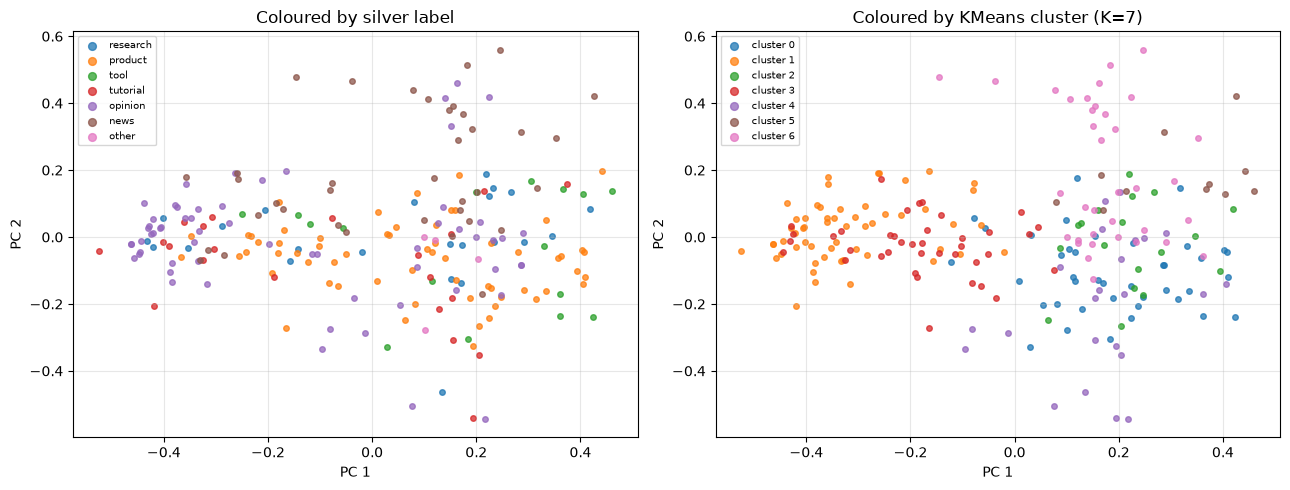

In [6]:
pca = PCA(n_components=2, random_state=0)
XY = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: colour by silver label
for cat in category_names():
    m = df["category"] == cat
    axes[0].scatter(XY[m, 0], XY[m, 1], s=16, alpha=0.75, label=cat)
axes[0].set_title("Coloured by silver label")
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")
axes[0].legend(fontsize=7, loc="best", markerscale=1.4)
axes[0].grid(True, alpha=0.3)

# Right: colour by KMeans cluster
for k in range(K):
    m = km_labels == k
    axes[1].scatter(XY[m, 0], XY[m, 1], s=16, alpha=0.75, label=f"cluster {k}")
axes[1].set_title(f"Coloured by KMeans cluster (K={K})")
axes[1].set_xlabel("PC 1")
axes[1].set_ylabel("PC 2")
axes[1].legend(fontsize=7, loc="best", markerscale=1.4)
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

**Reading the plots.** If the two colour maps look broadly
similar, the KMeans clusters are recovering the same semantic
structure the silver labels encode - just without any supervision.
If they look very different, either the embedding space
prioritises a different similarity (e.g. topic vs form) or the
label set does not carve the semantic space along its natural
folds.

## 6. Which cluster maps to which label?

For each KMeans cluster, print its majority silver label and the
top TF-IDF terms of the stories inside it. This is what makes
clusters *interpretable* - we can read them and name them.

In [7]:
def cluster_summary(cluster_labels, top_n_terms=6):
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, stop_words="english")
    M = tfidf.fit_transform(df["input_text"])
    feats = np.array(tfidf.get_feature_names_out())
    rows = []
    for c in sorted(set(cluster_labels)):
        if c == -1:
            continue
        mask = cluster_labels == c
        subset = df[mask]
        majority = subset["category"].value_counts().index[0]
        support = int(mask.sum())
        avg_vec = np.asarray(M[mask].mean(axis=0)).ravel()
        top_idx = np.argsort(avg_vec)[-top_n_terms:][::-1]
        rows.append({
            "cluster": c,
            "size": support,
            "majority_silver": majority,
            "top_terms": ", ".join(feats[top_idx]),
        })
    return pd.DataFrame(rows)


km_summary = cluster_summary(km_labels)
print("KMeans clusters:")
print(km_summary.to_string(index=False))

KMeans clusters:
 cluster  size majority_silver                                       top_terms
       0    40         product      x2f, claude, claude code, code, 27b, qwen3
       1    56         opinion  ai, age ai, people, age, mathematics, using ai
       2    18         product              llm, llms, x27, hn, verifier, quot
       3    39         product           ai, agents, hn, ai agents, agent, x2f
       4    23         opinion   chatgpt, claude, text, watermark, html, feeds
       5    11            news             cuda, gpu, apple, gpt sol, sol, gpt
       6    36            news openai, x2f, training, model, frontier, x2f x2f


In [8]:
hdb_summary = cluster_summary(hdb_labels)
print("HDBSCAN clusters:")
print(hdb_summary.to_string(index=False))

HDBSCAN clusters:
 cluster  size majority_silver                                                top_terms
       0    13         product                        llms, x27, llm, context, apis, hn
       1     6         opinion text, watermark, claude, claude watermark, works, remove
       2    78         opinion                ai, agents, x2f, ai agents, coding, agent
       3    14            news     openai, training, chatgpt, frontier, retention, zero


**Reading the summaries.** The `top_terms` column is what makes
each cluster *nameable*: `openai, funding, round` -> "OpenAI /
company news"; `claude, opus, prompt` -> "Claude Opus discussion";
`github, model, weights` -> "open-weight model releases". The
LangGraph agent in nb06 uses these cluster summaries as "extra
signal" beyond the fixed category labels.

## 7. Save embeddings + cluster assignments for nb06

In [9]:
np.save(ROOT / "data" / "embeddings.npy", X)

clusters_out = pd.DataFrame({
    "id": df["id"].values,
    "silver": df["category"].values,
    "kmeans": km_labels,
    "hdbscan": hdb_labels,
})
clusters_out.to_csv(ROOT / "data" / "clusters.csv", index=False)

# Also persist the per-cluster summaries for readability
km_summary.to_csv(ROOT / "data" / "kmeans_summary.csv", index=False)
hdb_summary.to_csv(ROOT / "data" / "hdbscan_summary.csv", index=False)

print(f"saved embeddings.npy         (shape={X.shape})")
print(f"saved clusters.csv           ({len(clusters_out)} rows)")
print(f"saved kmeans_summary.csv     ({len(km_summary)} rows)")
print(f"saved hdbscan_summary.csv    ({len(hdb_summary)} rows)")

saved embeddings.npy         (shape=(223, 384))
saved clusters.csv           (223 rows)
saved kmeans_summary.csv     (7 rows)
saved hdbscan_summary.csv    (4 rows)


## Takeaways for notebook 06

- Sentence embeddings live in `data/embeddings.npy` (223 x 384).
- Cluster assignments per story live in `data/clusters.csv`
  (silver + KMeans-7 + HDBSCAN columns).
- Per-cluster majority label + top-term summaries live in
  `data/kmeans_summary.csv` and `data/hdbscan_summary.csv` for
  human readability.
- The LangGraph agent in notebook 06 uses (a) the LLM
  classifier from nb04 as its per-story category signal and (b)
  cluster membership from here as a secondary "theme" signal so
  the drill-down node can pull all stories in the same cluster,
  not just the same category.